<a href="https://colab.research.google.com/github/IC-Automocao-eq/Controle_codigo_oscila-es_variaveis/blob/main/Controle_Aline_estatistica_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

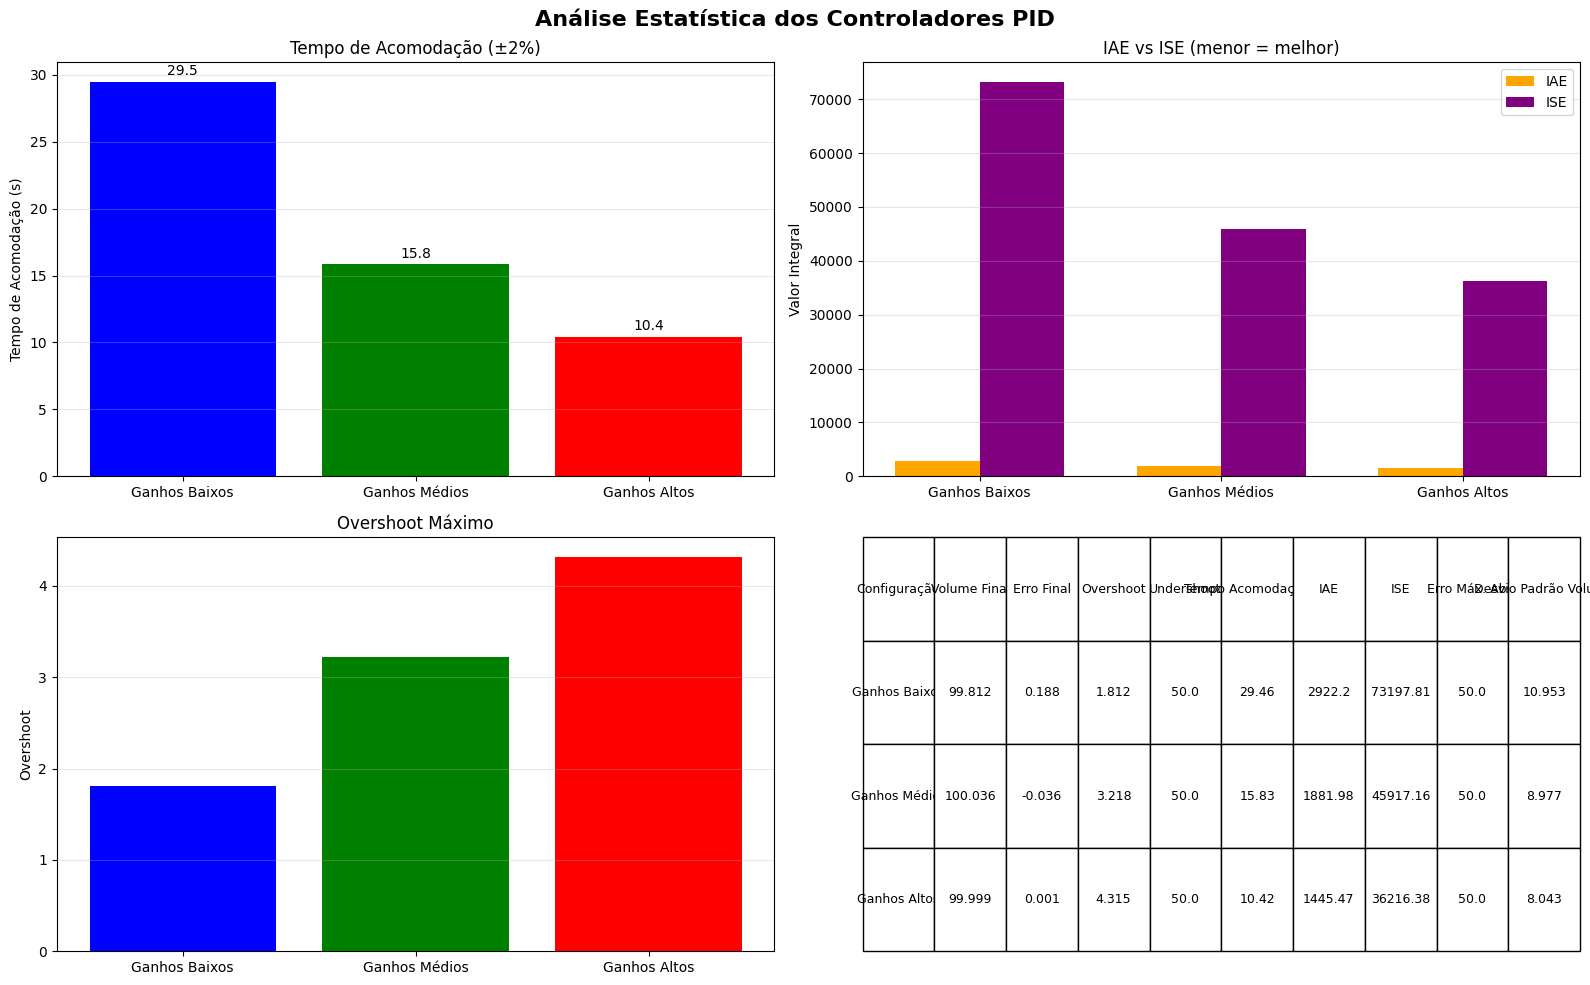

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.table import table

# ====================== ESTATÍSTICAS ======================
def calcular_estatisticas(t, V, erro, nome):
    idx_acomod = np.where((V >= 98) & (V <= 102))[0]
    tempo_acomod = t[idx_acomod[0]] if len(idx_acomod) > 0 else np.nan

    return {
        'Configuração': nome,
        'Volume Final': round(V[-1], 3),
        'Erro Final': round(100 - V[-1], 3),
        'Overshoot': round(max(0, np.max(V) - 100), 3),
        'Undershoot': round(100 - np.min(V), 3) if np.min(V) < 100 else 0,
        'Tempo Acomodação (s)': round(tempo_acomod, 2),
        'IAE': round(np.sum(np.abs(erro)), 2),
        'ISE': round(np.sum(erro**2), 2),
        'Erro Máx. Abs.': round(np.max(np.abs(erro)), 3),
        'Desvio Padrão Volume': round(np.std(V), 3)
    }

# Calcula estatísticas
stats1 = calcular_estatisticas(t1, V1, erro1, "Ganhos Baixos")
stats2 = calcular_estatisticas(t2, V2, erro2, "Ganhos Médios")
stats3 = calcular_estatisticas(t3, V3, erro3, "Ganhos Altos")

stats_list = [stats1, stats2, stats3]

# ====================== GRÁFICOS ESTATÍSTICOS ======================
fig_stats, axs = plt.subplots(2, 2, figsize=(16, 10))
fig_stats.suptitle('Análise Estatística dos Controladores PID', fontsize=16, fontweight='bold')

# Gráfico 1: Tempo de Acomodação (Barra)
nomes = [s['Configuração'] for s in stats_list]
tempos = [s['Tempo Acomodação (s)'] for s in stats_list]
bars = axs[0, 0].bar(nomes, tempos, color=['blue', 'green', 'red'])
axs[0, 0].set_ylabel('Tempo de Acomodação (s)')
axs[0, 0].set_title('Tempo de Acomodação (±2%)')
axs[0, 0].grid(axis='y', alpha=0.3)
for bar in bars:
    axs[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f'{bar.get_height():.1f}', ha='center')

# Gráfico 2: IAE e ISE (Barras agrupadas)
x = np.arange(len(nomes))
width = 0.35

iae = [s['IAE'] for s in stats_list]
ise = [s['ISE'] for s in stats_list]

axs[0, 1].bar(x - width/2, iae, width, label='IAE', color='orange')
axs[0, 1].bar(x + width/2, ise, width, label='ISE', color='purple')
axs[0, 1].set_ylabel('Valor Integral')
axs[0, 1].set_title('IAE vs ISE (menor = melhor)')
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(nomes)
axs[0, 1].legend()
axs[0, 1].grid(axis='y', alpha=0.3)

# Gráfico 3: Overshoot
overshoots = [s['Overshoot'] for s in stats_list]
axs[1, 0].bar(nomes, overshoots, color=['blue', 'green', 'red'])
axs[1, 0].set_ylabel('Overshoot')
axs[1, 0].set_title('Overshoot Máximo')
axs[1, 0].grid(axis='y', alpha=0.3)

# Gráfico 4: Tabela Resumo
axs[1, 1].axis('off')
col_labels = list(stats_list[0].keys())
cell_text = [[str(stats_list[i][key]) for key in col_labels] for i in range(3)]

tab = axs[1, 1].table(cellText=cell_text,
                      colLabels=col_labels,
                      cellLoc='center',
                      loc='center',
                      bbox=[0, 0, 1, 1])

tab.auto_set_font_size(False)
tab.set_fontsize(9)
tab.scale(1.2, 1.8)

plt.tight_layout()
plt.show()